# Spatial and Non-Spatial data output project




## `Spatial visualisations`

In [13]:
# install required packages

!pip install contextily
!pip install geoplot
!pip install git+https://github.com/pmdscully/geo_northarrow.git
!pip install mapclassify
!pip install geodatasets
!pip install matplotlib-scalebar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 73.4 MB/s eta 0:00:00
  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-n9su1xn7
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-n9su1xn7
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for geo_northarrow: filename=geo_northarrow-0.2.0a0-py3-none-any.whl size=14940 sha256=6a16da74fec083a4ff929cac9076c981371734f55f548ac53d38ae174e2c0201
  Stored in directory: /tmp/pip-ephem-wheel-cache-zhze9zsv/wheels/d7/28/6c/cb006605c19bc4f58db715626f7113a6858d8c002e8c52fa80
Successfully built geo_northarrow


In [14]:
# Import packages
import geopandas as gpd
import geodatasets
from geo_northarrow import add_north_arrow
import contextily as cx
from matplotlib_scalebar.scalebar import ScaleBar

In [15]:
#Load in the data sets using geopandas .geoson/.gpkg files and pandas for .csv file
manchester = gpd.read_file('/content/Output_Areas_Dec_2011_Boundaries_EW_BFC_2022_-2333695623809372811.geojson')
elderly = pd.read_csv('manchester elderly.csv')
poi_df = gpd.read_file('/content/poi_6156893.gpkg')

**Investigating the dataset**

In [16]:
# Inspect the top 10 rows of the manchester dataset
manchester.head(10)

,OBJECTID,OA11CD,LAD11CD,LAD16CD,LAD16NM,GlobalID,geometry
0,26063,E00026917,E08000003,E08000003,Manchester,d444d918-a078-4a37-b398-9b9de8f7180e,"POLYGON ((-2.27565 53.37658, -2.27572 53.3764,..."
1,25161,E00025939,E08000003,E08000003,Manchester,a9393559-5222-4bb2-b930-1c273e70e6a5,"POLYGON ((-2.20645 53.43272, -2.20614 53.4324,..."
2,25777,E00026620,E08000003,E08000003,Manchester,c3908d0d-9c41-4a5d-b64f-4342445fb817,"POLYGON ((-2.19011 53.49731, -2.1896 53.49707,..."
3,25445,E00026265,E08000003,E08000003,Manchester,e31f6c91-a99f-4161-b448-3b94c3654a10,"POLYGON ((-2.18801 53.46862, -2.18801 53.46862..."
4,25090,E00025866,E08000003,E08000003,Manchester,09cd1482-129c-422f-a8c0-7c1e59c689ae,"POLYGON ((-2.30549 53.40612, -2.30547 53.40613..."
5,25754,E00026597,E08000003,E08000003,Manchester,63980c64-0553-48bc-9c21-a10b32a3b954,"POLYGON ((-2.16224 53.51896, -2.16221 53.51894..."
6,24904,E00025661,E08000003,E08000003,Manchester,bbe3b1b1-f635-408f-9b4f-991279e08674,"POLYGON ((-2.28508 53.39783, -2.28494 53.39782..."
7,25562,E00026396,E08000003,E08000003,Manchester,c8d7a683-6dcd-4264-bef4-404ace5278ce,"POLYGON ((-2.25495 53.4652, -2.25496 53.46521,..."
8,24921,E00025678,E08000003,E08000003,Manchester,e1d641c3-f5ee-4f0a-bafd-a5a83f864f75,"POLYGON ((-2.26705 53.43138, -2.26734 53.4312,..."
9,25585,E00026421,E08000003,E08000003,Manchester,f2d0077c-d529-45f5-9582-0438252b4848,"POLYGON ((-2.19971 53.44176, -2.19971 53.44176..."


In [17]:
# Inspect Machester elderly ages data set
elderly.head()

,2011_output_area,OA11CD,all_residents,65_74_number,75_84_number,85_89_number,90_over_number
0,E00025804,E00025804,186,25,12,3,2
1,E00025806,E00025806,252,28,13,9,2
2,E00025826,E00025826,286,18,10,4,3
3,E00025828,E00025828,296,24,16,4,2
4,E00025829,E00025829,191,26,14,3,0


In [18]:
# Check data types of the manchester elderly data set
elderly.dtypes

,0
2011_output_area,object
OA11CD,object
all_residents,int64
65_74_number,int64
75_84_number,int64
85_89_number,int64
90_over_number,int64


**Data Processing**

In [19]:
# Drop the 65_74_number column
elderly = elderly.drop(columns=['65_74_number'])

In [20]:
# Add all number columns (int64) together to create a new column of total elderly people in Machester
elderly['total_elderly'] = elderly['75_84_number']+ elderly['85_89_number']+ elderly['90_over_number']

In [21]:
# Check to see if new column has been created
elderly.head()

,2011_output_area,OA11CD,all_residents,75_84_number,85_89_number,90_over_number,total_elderly
0,E00025804,E00025804,186,12,3,2,17
1,E00025806,E00025806,252,13,9,2,24
2,E00025826,E00025826,286,10,4,3,17
3,E00025828,E00025828,296,16,4,2,22
4,E00025829,E00025829,191,14,3,0,17


In [22]:
# Create new column with total elderly population divided by the total number of residents to give a percentage total
elderly['total_elderly_perc'] = elderly['total_elderly'] / elderly['all_residents']*100

In [23]:
# Check that the new column has been added correctly
elderly.head()

,2011_output_area,OA11CD,all_residents,75_84_number,85_89_number,90_over_number,total_elderly,total_elderly_perc
0,E00025804,E00025804,186,12,3,2,17,9.139785
1,E00025806,E00025806,252,13,9,2,24,9.523810
2,E00025826,E00025826,286,10,4,3,17,5.944056
3,E00025828,E00025828,296,16,4,2,22,7.432432
4,E00025829,E00025829,191,14,3,0,17,8.900524


In [24]:
# Check CRS of Manchester
manchester.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [25]:
# Change CRS to British National Grid (EPSG:27700), units in meters
manchester_new_proj = manchester.to_crs('27700')

In [26]:
# Check if the CRS change has been succsessful
manchester_new_proj.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

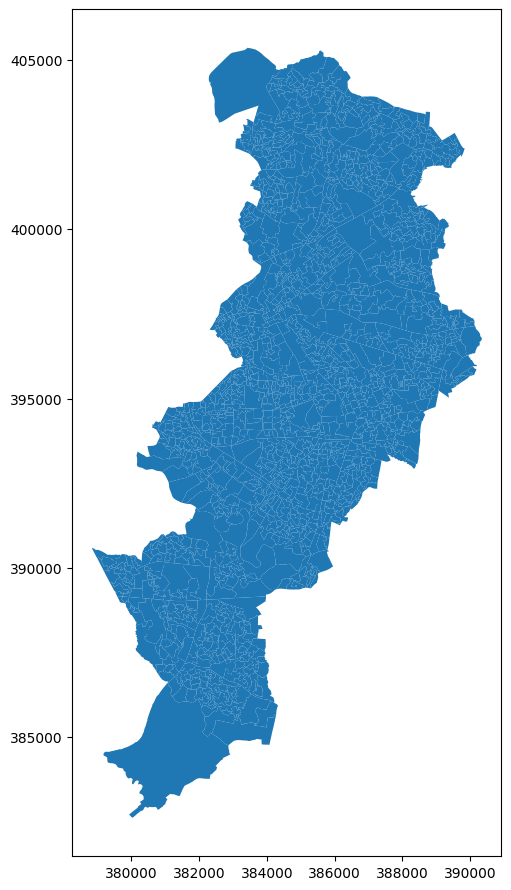

In [27]:
# Plot the manchester data to see what it looks like
# Define the number of plots and figure size
f, ax = plt.subplots(1, figsize=(18, 11))

# Plotting the manchester newly projected data, specifying the subplot axis
manchester_new_proj.plot(ax=ax)

# Show the plot
plt.show()

In [28]:
# View POI data showing the top 10 rows
poi_df.head(10)

,ref_no,name,pointx_class,groupname,categoryname,classname,feature_easting,feature_northing,pos_accuracy,uprn,...,postcode,admin_boundary,telephone_number,url,brand,qualifier_type,qualifier_data,provenance,supply_date,geometry
0,166807712,Dacia Manchester,09490695,Retail,Motoring,New Vehicles,383290.0,398981.0,1,1.000468e+10,...,M3 7FT,Salford District,01617171370,www.retailgroup.co.uk/dacia/find-a-dealer/daci...,Retail Group,None,None,118 Information,2025-09-01,POINT (383290 398981)
1,107654869,Caspian Motor Co,09490695,Retail,Motoring,New Vehicles,387753.0,393524.0,1,7.715834e+07,...,M19 2TW,Manchester District,01612923208,None,None,None,None,118 Information,2025-09-01,POINT (387753 393524)
2,105224537,The Car Centre,09490695,Retail,Motoring,New Vehicles,386413.5,393952.1,1,7.725011e+07,...,M14 6PD,Manchester District,01612244500,www.thecarcentreuk.com,None,None,None,118 Information,2025-09-01,POINT (386413.5 393952.1)
3,124784983,Pentagon Vauxhall,09490695,Retail,Motoring,New Vehicles,388346.0,404418.0,1,1.000129e+11,...,M24 1SW,Oldham District,01616541416,www.pentagon-group.co.uk,Vauxhall,None,None,118 Information,2025-09-01,POINT (388346 404418)
4,85605059,Brayleys,09490695,Retail,Motoring,New Vehicles,385691.0,397484.0,1,1.002305e+10,...,M12 6JZ,Manchester District,01614253283,www.brayleys.co.uk,Nissan,None,None,118 Information,2025-09-01,POINT (385691 397484)
5,48879924,Inchcape Volkswagen,09490695,Retail,Motoring,New Vehicles,382055.0,396606.0,1,1.007045e+10,...,M16 9SF,Trafford District,01616071313,www.inchcape.co.uk,Volkswagen,None,None,118 Information,2025-09-01,POINT (382055 396606)
6,168968272,My Car Agents,09490695,Retail,Motoring,New Vehicles,388469.0,403224.0,1,7.704015e+07,...,M40 0JL,Manchester District,08002335111,None,None,None,None,118 Information,2025-09-01,POINT (388469 403224)
7,146514569,Robins & Day Manchester,09490695,Retail,Motoring,New Vehicles,384820.0,396904.0,1,7.711845e+07,...,M13,Manchester District,01616367483,None,Citroen,None,None,118 Information,2025-09-01,POINT (384820 396904)
8,129882194,Smart Manchester,09490695,Retail,Motoring,New Vehicles,386491.0,398418.0,1,1.002306e+10,...,M11,Manchester District,03332220600,www.smart.com,None,None,None,118 Information,2025-09-01,POINT (386491 398418)
9,159601742,Sedgley Group,09490695,Retail,Motoring,New Vehicles,382009.0,402366.0,1,1.000127e+11,...,M25 9WD,Bury District,01617506070,www.sedgleygroup.co.uk,None,None,None,118 Information,2025-09-01,POINT (382009 402366)


In [29]:
# Filter to just manchester district to get POIs within manchester area
manchester_poi = poi_df[poi_df['admin_boundary'] == 'Manchester District']

In [30]:
# Veiw the data set
manchester_poi

,ref_no,name,pointx_class,groupname,categoryname,classname,feature_easting,feature_northing,pos_accuracy,uprn,...,postcode,admin_boundary,telephone_number,url,brand,qualifier_type,qualifier_data,provenance,supply_date,geometry
1,107654869,Caspian Motor Co,09490695,Retail,Motoring,New Vehicles,387753.0,393524.0,1,7.715834e+07,...,M19 2TW,Manchester District,01612923208,None,None,None,None,118 Information,2025-09-01,POINT (387753 393524)
2,105224537,The Car Centre,09490695,Retail,Motoring,New Vehicles,386413.5,393952.1,1,7.725011e+07,...,M14 6PD,Manchester District,01612244500,www.thecarcentreuk.com,None,None,None,118 Information,2025-09-01,POINT (386413.5 393952.1)
4,85605059,Brayleys,09490695,Retail,Motoring,New Vehicles,385691.0,397484.0,1,1.002305e+10,...,M12 6JZ,Manchester District,01614253283,www.brayleys.co.uk,Nissan,None,None,118 Information,2025-09-01,POINT (385691 397484)
6,168968272,My Car Agents,09490695,Retail,Motoring,New Vehicles,388469.0,403224.0,1,7.704015e+07,...,M40 0JL,Manchester District,08002335111,None,None,None,None,118 Information,2025-09-01,POINT (388469 403224)
7,146514569,Robins & Day Manchester,09490695,Retail,Motoring,New Vehicles,384820.0,396904.0,1,7.711845e+07,...,M13,Manchester District,01616367483,None,Citroen,None,None,118 Information,2025-09-01,POINT (384820 396904)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32194,164704515,Bravo Tango Cleaning Services Ltd,02070100,Commercial Services,Contract Services,Contract Cleaning Services,386523.0,400320.0,1,1.009189e+10,...,M40 8WN,Manchester District,03300010241,None,None,None,None,118 Information,2025-09-01,POINT (386523 400320)
32195,167593153,Kama Support Services Ltd,02070100,Commercial Services,Contract Services,Contract Cleaning Services,384128.8,397833.9,1,7.711966e+07,...,M1 6DN,Manchester District,07538187045,None,None,None,None,118 Information,2025-09-01,POINT (384128.8 397833.9)
32196,164696810,Pure Decon,02070100,Commercial Services,Contract Services,Contract Cleaning Services,383848.0,391644.0,1,7.709074e+07,...,M20 2PW,Manchester District,01618219999,None,None,None,None,118 Information,2025-09-01,POINT (383848 391644)
32197,129827750,Superious Cleaning Co,02070100,Commercial Services,Contract Services,Contract Cleaning Services,381586.0,389146.0,1,7.705287e+07,...,M23 1AG,Manchester District,07969643701,None,None,None,None,118 Information,2025-09-01,POINT (381586 389146)


In [31]:
# Filter the new dataframe by 'classname' to create a new dataframe containing just Nursing and Residential Care Homes
nursing_carehomes_df = manchester_poi[manchester_poi['classname']== 'Nursing and Residential Care Homes']

In [32]:
# View the care and nursing facilities data
nursing_carehomes_df.head()

,ref_no,name,pointx_class,groupname,categoryname,classname,feature_easting,feature_northing,pos_accuracy,uprn,...,postcode,admin_boundary,telephone_number,url,brand,qualifier_type,qualifier_data,provenance,supply_date,geometry
26662,103917740,The White House Care Home,05280373,Education and Health,Health Practitioners and Establishments,Nursing and Residential Care Homes,382187.0,390075.0,1,7.708058e+07,...,M23 0DJ,Manchester District,01619987632,None,None,None,None,HSJ Information Limited,2025-09-01,POINT (382187 390075)
26663,103910897,Cornish Close Care Home,05280373,Education and Health,Health Practitioners and Establishments,Nursing and Residential Care Homes,382912.0,385895.0,1,1.007086e+10,...,M22 0GJ,Manchester District,01614363848,None,None,None,None,HSJ Information Limited,2025-09-01,POINT (382912 385895)
26664,103910865,Outreach Care Home,05280373,Education and Health,Health Practitioners and Establishments,Nursing and Residential Care Homes,383343.0,402304.0,1,7.700190e+07,...,M7 4QY,Manchester District,01617400471,None,None,None,None,HSJ Information Limited,2025-09-01,POINT (383343 402304)
26666,103910854,Bradgate Close Care Home,05280373,Education and Health,Health Practitioners and Establishments,Nursing and Residential Care Homes,383218.0,389589.0,1,7.706768e+07,...,M22 4LX,Manchester District,01619455810,None,None,None,None,HSJ Information Limited,2025-09-01,POINT (383218 389589)
26667,103910903,Sidney Road,05280373,Education and Health,Health Practitioners and Establishments,Nursing and Residential Care Homes,385746.0,402266.0,1,7.701791e+07,...,M9 8AT,Manchester District,01612057314,None,None,None,None,HSJ Information Limited,2025-09-01,POINT (385746 402266)


In [33]:
# Veiw the CRS of the nursing and carehome dataframe
nursing_carehomes_df.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

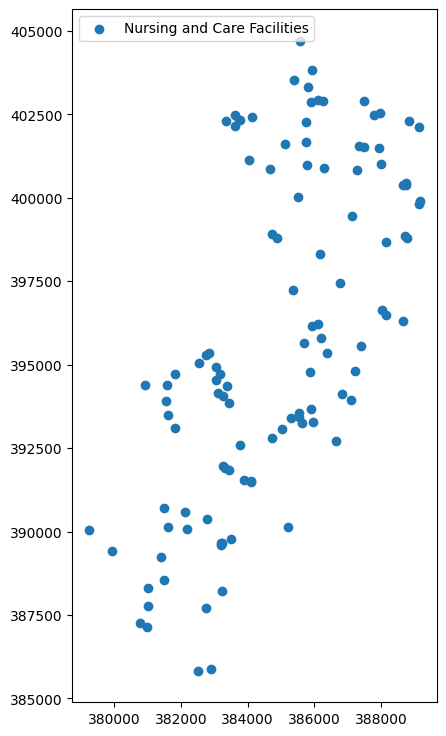

In [34]:
# Plot the nursing/care facility data to visualise the shape

# Create 1 plot setting the size to 16x9
f, ax = plt.subplots(1, figsize=(16, 9))

# Plot the point data stating the subplot axis, give the data a label so it can easiliy be plotted as a legend
nursing_carehomes_df.plot(ax=ax, label = 'Nursing and Care Facilities')

# Plot legend and give it a location eg.upper left
plt.legend(loc = 'upper left')

# Show the plot
plt.show()


In [35]:
# Merge the two datasets into one, joining on the common OA11CD columns
manchester_elderly = pd.merge(manchester_new_proj, elderly, on='OA11CD')

In [36]:
# Check to see if the merge has worked correctly
manchester_elderly.head()

,OBJECTID,OA11CD,LAD11CD,LAD16CD,LAD16NM,GlobalID,geometry,2011_output_area,all_residents,75_84_number,85_89_number,90_over_number,total_elderly,total_elderly_perc
0,26063,E00026917,E08000003,E08000003,Manchester,d444d918-a078-4a37-b398-9b9de8f7180e,"POLYGON ((381759.089 386671, 381754.77 386650....",E00026917,405,16,9,3,28,6.913580
1,25161,E00025939,E08000003,E08000003,Manchester,a9393559-5222-4bb2-b930-1c273e70e6a5,"POLYGON ((386380.823 392901.953, 386401.404 39...",E00025939,310,11,2,0,13,4.193548
2,25777,E00026620,E08000003,E08000003,Manchester,c3908d0d-9c41-4a5d-b64f-4342445fb817,"POLYGON ((387485.911 400084.493, 387519.88 400...",E00026620,331,8,1,1,10,3.021148
3,25445,E00026265,E08000003,E08000003,Manchester,e31f6c91-a99f-4161-b448-3b94c3654a10,"POLYGON ((387616.578 396892.589, 387616.7 3968...",E00026265,262,13,2,1,16,6.106870
4,25090,E00025866,E08000003,E08000003,Manchester,09cd1482-129c-422f-a8c0-7c1e59c689ae,"POLYGON ((379788.284 389966.353, 379789.802 38...",E00025866,260,27,10,7,44,16.923077


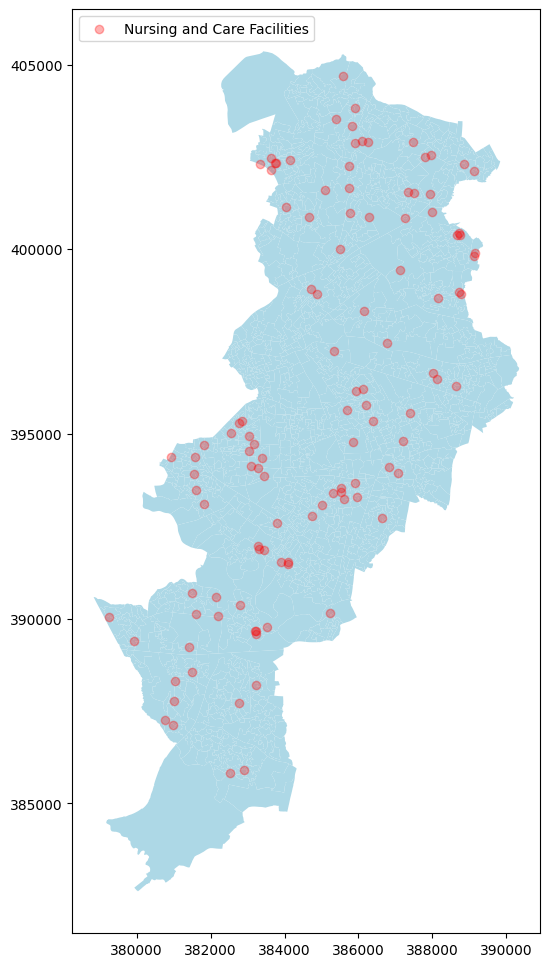

In [37]:
# Plot a subplot with a figure size of 20x12
f, ax = plt.subplots(1, figsize=(20, 12))

# Set the base map to manchester elderly and colour the basemap lightblue
base = manchester_elderly.plot(ax=ax, color='lightblue')

# Plot the nursing/care home facilities on the basemap plot, colour the points red and set the opacity at 0.3
nursing_carehomes_df.plot(ax=base,color='red', alpha = 0.3, label = 'Nursing and Care Facilities')

# Plot legend and a location eg.upper left
plt.legend(loc = 'upper left')

# Show the map
plt.show()

**Data visualisation**

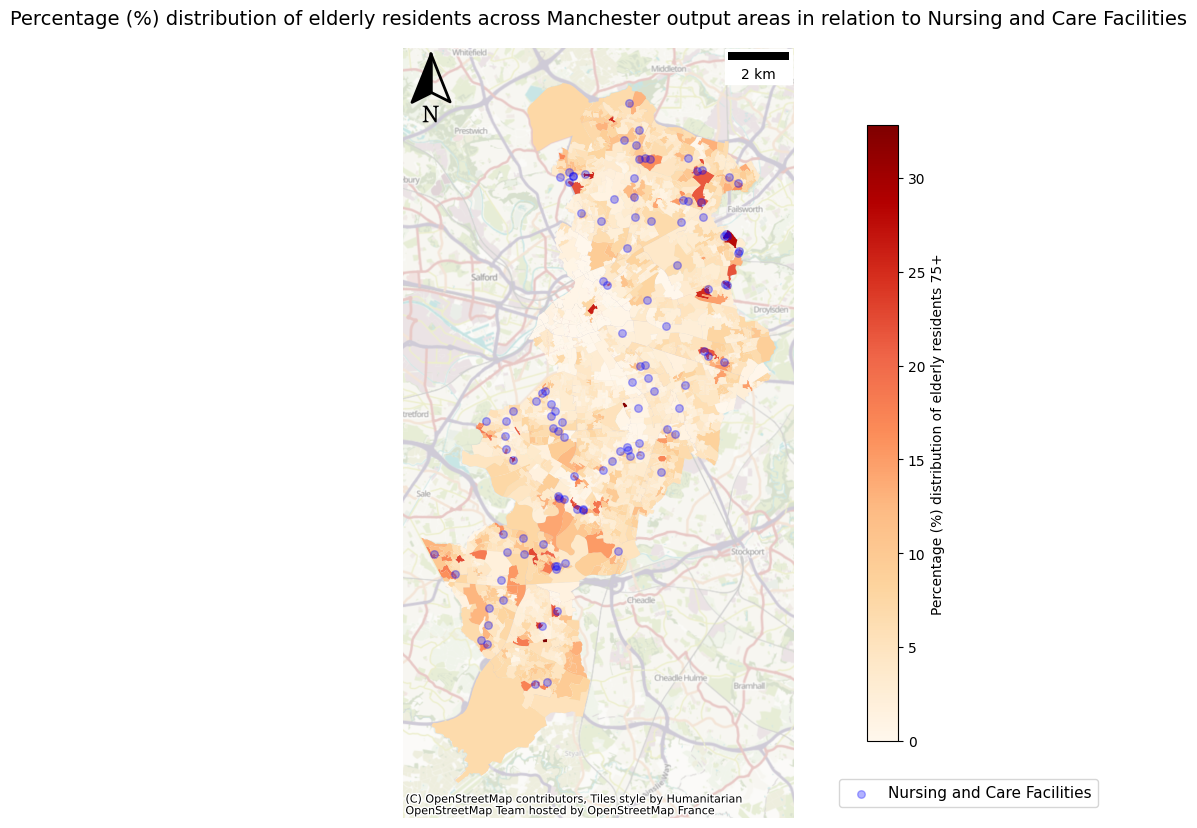

In [38]:
#Final Plot

#Create a map plot showing a chloropleth map of manchester and the distribution of elderly residents
# Define plot size
f,ax = plt.subplots(1, figsize=(19,10))


# Plot the OA11CD, specifying to plot the 'Total Elderly Percentage' column
# Set the basemap to manchester elderly visualising the total elderly percentage, Add legend (legend =True)
# Change the colour scheme to orange/red (better for percentages), shrink the legend to 0.7
base = manchester_elderly.plot( ax=ax, column ='total_elderly_perc', legend = True, cmap='OrRd',
                               legend_kwds={'shrink': 0.8, 'label': 'Percentage (%) distribution of elderly residents 75+'})


# plot the nursing/care home facilities on the basemap plot, colour the points red and set the opacity at 0.3
nursing_carehomes_df.plot(ax=base, color='blue', alpha = 0.3,  markersize=30, legend = True, label ='Nursing and Care Facilities')
cx.add_basemap(ax, crs = 'EPSG:27700', alpha = 0.5)

# Plot a title
plt.title('Percentage (%) distribution of elderly residents across Manchester output areas in relation to Nursing and Care Facilities', y = 1.02, fontsize = 14)

# Add a north arrow, plot on axis positioning it in a suitable place on the map set the scale
add_north_arrow(ax=ax, xlim_pos=0.07, ylim_pos=.93, text_scaler=2.5, text_yT=-1.25, scale=.75)


# Add a scalebar setting the pixel equal to 1m (Copilot was used to suggest a package containing a scalebar function)
scalebar = ScaleBar(1)
ax.add_artist(scalebar)


# Add legend increase the font size to 11 and move to below chloropleth legend so that there is no overlap
plt.legend(fontsize=11)
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.80,0.06))

# Remove axis
ax.set_axis_off()

# Show the map
plt.show()

### **Spatial output evaluation**
The aim of block two was to plot percentage density of elderly residents (75 and above) in relation to nursing and care facilities. Data type, common columns and CRS where identified all to provide a clear and accurate final visualisation.  Data processing was then undertaken, new columns where added to the Manchester Elderly dataset to show total elderly population as well as percentage so that a choropleth map could be created. The CRS of the Manchester shapefile was change from a geographic CRS  (degrees) to British National Grid (meters) to provide a more accurate projection. As well as this, the POI dataset was filtered to create a new subset only containing Nursing and Care facility data points.

A choropleth map was chosen to visualise this data as it presents the information truthfully, grouped ‘bin’ categories may have been misleading as large percentage ranges would be grouped together rather than displaying individual values leading to inaccurate interpretation of elderly percentage distribution in relation to POI data.

The choropleth map was set as colour scheme ‘OrRd’, this palette makes areas of high percentage easy to identify, the colour bar was shrunk to allow the addition on the POI legend below it. Labels where added to both legends and the POI label was increased in size to make it clearer. The colour of the POI data points was set to ‘blue’ due to it high contrast between the lighter orange, the opacity of the points was decreased and there size was increased. A scalebar, north arrow and OS base map were added to put  the plot into real world context, the base map opacity was decreased and axis removed as to not distract from the presented data, furthermore, the north arrow was moved so that it was not covering the plot.








# `Non-spatial`

In [1]:
# import required packages

# for data manipulation
import pandas as pd
import numpy as np

# for data visulaisation
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load the iris data set from seaborn
iris = sns.load_dataset("iris")

**Investigating the dataset**

In [3]:
# Describing the dataset
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Infomation on the dataset
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# Print the mean petal length
iris['petal_length'].mean()

np.float64(3.7580000000000005)

In [6]:
# Print the mean petal width
iris['petal_width'].mean()

np.float64(1.1993333333333336)

**Data Processing**

In [7]:
# Describe the data types
iris.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [8]:
# Data-preprocessing
# Checking for missing values
iris.isna()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [9]:
# Checking for duplicates
iris.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
145,False
146,False
147,False
148,False


In [10]:
# Create a subset containing only the Petal width/length and Species columns
iris_petals_sub = iris[['petal_length', 'petal_width', 'species']]

In [11]:
# Veiw the new subset
iris_petals_sub

,petal_length,petal_width,species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa
...,...,...,...
145,5.2,2.3,virginica
146,5.0,1.9,virginica
147,5.2,2.0,virginica
148,5.4,2.3,virginica


**Data Visualisation**

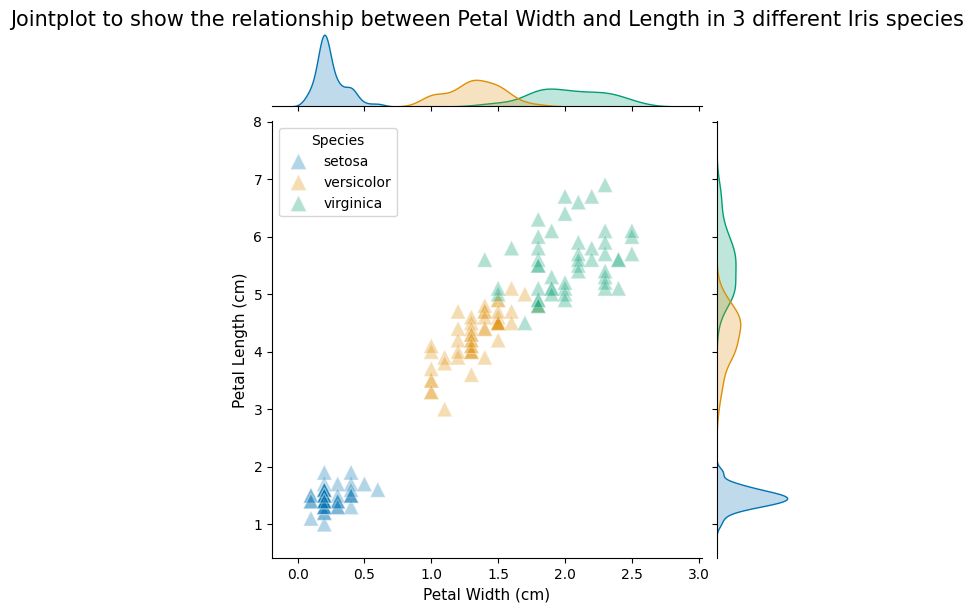

In [12]:
# Data visualisation basic scatterplot

# Create a jointplot using the iris subplot setting the x axis to petal width and the y axis to petal length, set the hue to species and chnage to the marker to a triangle shape
# Set the palette to colour blind friendly and change the marker size to 120 and opacity at 0.3.
sns.jointplot(data = iris_petals_sub, x = 'petal_width', y = 'petal_length', hue = 'species', marker ='^', palette = "colorblind", s = 120, alpha = 0.3)

# Set the title of the plot and plot it, position the title above the plot and inlarge the fontsize (Copilot was used to help move the title above the plot)
plt.title('Jointplot to show the relationship between Petal Width and Length in 3 different Iris species', y= 1.2, fontsize = 15)

# PLot the x and y lables adding in units, make the font size bigger
plt.xlabel("Petal Width (cm)", fontsize= 11)
plt.ylabel("Petal Length (cm)", fontsize = 11)

# Change the tile of the legend so it is easily understandable
plt.legend(title = 'Species')

# Show the plot
plt.show()

### **Final non-spatial output evaluation**
In block one the aim was to visualise the Seaborn ‘Iris’ data set comparing ‘Petal Length’ and ‘Petal Width’ per species. The appropriate packages where imported and data was investigated, data processing was then conducted to inspect the data for null values and duplicates. The Iris data was already clean, however if there had been any missing/duplicate values these would have been removed using the .dropna() and .drop_duplicates() functions. A data subset was created only containing columns used in the visualisation (petal width/length and species).

A jointplot was used for the visualisation of data containing a scatterplot to show the comparison between both factors as well as a kernel density plot to show the distribution of points. A scatterplot is a simple but effective way of visualising 2 numerical (float64) factors, in this case the data is displayed in a way that is comprehensive and clear with patterns clearly identifiable. The use of the kde plot is useful as there is clear clustering of points as well as overlap, the plot allows for clear understanding of point density. The opacity of the points was decreased to help aid density visualisation with darker areas suggesting a higher proportion of points. Points where coloured by species (object data type) to show if correlations varied depending on species type, the palette was changed to ‘colorblind’ to make visualisation more accessible. Point size was also increased and the marker for changed from default to a triangle to help make the plot clearer. The plot title and axis where increased in size and the title was moved up on the Y axis as before it was covered by the kde plot.












    

## Acknowledgements



"I acknowledge the use of Co-pilot (Microsoft Copilot, https://copilot.microsoft.com/, Accessed 2025-11-20) to give code suggestions for moving my plot title so that it was not overlapping my presented data. Prompt: How do I move my plt.title() above my plot so there is no overlap".

"I acknowledge the use of Co-Pilot (Microsoft Copilot, https://copilot.microsoft.com/, Accessed 2025-11-18) to give package suggestions for a scale bar. Prompt: What package could i import so that i could add a scale bar function".

###**Data Sources**
Odnance Survey, Digimaps Ordnance Survey Collection, POI data, https://digimap.edina.ac.uk/roam/map/os, Accsessed 2025-11-12.

Office for National Statistics, Geoportal, 2011 Census Output Areas, https://geoportal.statistics.gov.uk/datasets/417d65831892486bb88002c2e23520c1_0/explore, Accsessed 2025-11-12.

Office for National Statistics, Nomis 2011 Census data, Age Structure, https://www.nomisweb.co.uk/census/2011/ks102ew, Accsessed 2025-11-12.
